## vérification des % vide par colonne

In [3]:
import pandas as pd

path = "../data/raw/data_dvf_conso.csv.gz"
chunk_size = 1000000
total_missing = None
total_rows = 0

print("Analyse de la qualité des données en cours...")

for chunk in pd.read_csv(path, compression="gzip", chunksize=chunk_size, low_memory=False):
    if total_missing is None:
        total_missing = chunk.isnull().sum()
    else:
        total_missing += chunk.isnull().sum()
    total_rows += len(chunk)

# Calcul du pourcentage de vide par colonne
missing_pct = (total_missing / total_rows) * 100
missing_report = pd.DataFrame({'Colonnes': total_missing.index, 'Taux_Vide_%': missing_pct.values})
print(missing_report.sort_values(by='Taux_Vide_%', ascending=False))

Analyse de la qualité des données en cours...
                        Colonnes  Taux_Vide_%
16            ancien_id_parcelle    99.999910
14            ancien_nom_commune    99.997553
13           ancien_code_commune    99.997553
27           lot5_surface_carrez    99.971661
25           lot4_surface_carrez    99.920732
17                 numero_volume    99.774255
26                   lot5_numero    99.760898
23           lot3_surface_carrez    99.681058
24                   lot4_numero    99.462735
22                   lot3_numero    98.348658
21           lot2_surface_carrez    97.163073
36       nature_culture_speciale    95.706431
35  code_nature_culture_speciale    95.706431
6                adresse_suffixe    95.497728
19           lot1_surface_carrez    91.180674
20                   lot2_numero    90.805785
18                   lot1_numero    68.639731
31           surface_reelle_bati    65.895916
32     nombre_pieces_principales    40.915434
29               code_type_local  

## Chargement df et Elagage 

In [1]:
import pandas as pd
import gc

path = "../data/raw/data_dvf_conso.csv.gz"

# Ta liste exacte de colonnes à conserver
cols_to_keep = [
    'id_mutation', 'date_mutation', 'numero_disposition', 'nature_mutation', 
    'valeur_fonciere', 'adresse_numero', 'adresse_code_voie', 'adresse_nom_voie',
    'code_postal', 'code_commune', 'nom_commune', 'code_departement', 'id_parcelle',
    'nombre_lots', 'type_local', 'code_type_local', 'surface_reelle_bati', 
    'nombre_pieces_principales', 'code_nature_culture', 'nature_culture', 
    'surface_terrain', 'longitude', 'latitude'
]

chunks = []
chunk_size = 200000 

print("Chargement progressif (200 000 lignes par bloc)...")

try:
    # On parcourt le fichier par petits morceaux
    for i, chunk in enumerate(pd.read_csv(path, 
                                         compression="gzip", 
                                         usecols=cols_to_keep, 
                                         chunksize=chunk_size, 
                                         low_memory=False)):
        
        # FILTRAGE : On ne garde que Maison et Appartement (comme convenu)
        # Cela permet de réduire la taille finale en mémoire tout en gardant tes colonnes
        filtered_chunk = chunk[chunk['type_local'].isin(['Maison', 'Appartement'])].copy()
        
        chunks.append(filtered_chunk)
        
        # Libération de la mémoire après chaque bloc
        del chunk
        gc.collect()
        
        if i % 10 == 0: # Pour suivre l'avancement toutes les 2M de lignes
            print(f"Bloc {i} traité... Environ {i * chunk_size} lignes lues.")

    # Assemblage final de tous les morceaux
    df = pd.concat(chunks, ignore_index=True)
    print(f"✅ Terminé ! Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

except MemoryError:
    print("❌ Erreur de mémoire : Trop de colonnes pour la RAM. Essayez de fermer les autres logiciels.")

Chargement progressif (200 000 lignes par bloc)...
Bloc 0 traité... Environ 0 lignes lues.
Bloc 10 traité... Environ 2000000 lignes lues.
Bloc 20 traité... Environ 4000000 lignes lues.
Bloc 30 traité... Environ 6000000 lignes lues.
Bloc 40 traité... Environ 8000000 lignes lues.
Bloc 50 traité... Environ 10000000 lignes lues.
Bloc 60 traité... Environ 12000000 lignes lues.
Bloc 70 traité... Environ 14000000 lignes lues.
Bloc 80 traité... Environ 16000000 lignes lues.
Bloc 90 traité... Environ 18000000 lignes lues.
Bloc 100 traité... Environ 20000000 lignes lues.
✅ Terminé ! Le dataset contient 6247215 lignes et 23 colonnes.


## Analayse de df

In [2]:
# 2. Audit rapide avant transformation
print("--- État avant consolidation ---")
print(f"Nombre de lignes : {len(df)}")
print("\nListe de toutes les colonnes présentes :")
print(df.columns.tolist())

--- État avant consolidation ---
Nombre de lignes : 6247215

Liste de toutes les colonnes présentes :
['id_mutation', 'date_mutation', 'numero_disposition', 'nature_mutation', 'valeur_fonciere', 'adresse_numero', 'adresse_nom_voie', 'adresse_code_voie', 'code_postal', 'code_commune', 'nom_commune', 'code_departement', 'id_parcelle', 'nombre_lots', 'code_type_local', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'code_nature_culture', 'nature_culture', 'surface_terrain', 'longitude', 'latitude']


## 1. Bloc Identité : Nettoyage et Traitement des Doublons

In [3]:
# 1. Calcul du nombre de doublons sur l'identifiant unique de mutation
n_dups = df.duplicated(subset=['id_mutation']).sum()
print(f"Nombre de lignes redondantes (même ID mutation) : {n_dups}")

Nombre de lignes redondantes (même ID mutation) : 1385578


In [6]:
# --- ENQUÊTE VISUELLE (Zéro mémoire) ---

# On regarde simplement les 50 premières lignes
# On trie par ID Mutation pour voir les regroupements parcelles
enquete = df.head(50).sort_values(by='id_mutation')

print("Analyse des 50 premières lignes pour comprendre les doublons :")
display(enquete[['id_mutation', 'id_parcelle', 'valeur_fonciere', 'type_local', 'surface_reelle_bati']])

Analyse des 50 premières lignes pour comprendre les doublons :


,id_mutation,id_parcelle,valeur_fonciere,type_local,surface_reelle_bati
3,2020-11,01053000BX0263,169111.00,Maison,86.0
4,2020-12,011770000B0192,190000.00,Maison,114.0
5,2020-13,013700000B0003,179970.00,Appartement,61.0
6,2020-14,01053000AB0296,360000.00,Appartement,118.0
7,2020-15,01053000AM0095,136000.00,Appartement,62.0
8,2020-18,013140000D2672,225000.00,Maison,108.0
9,2020-19,01184000AK0222,145590.00,Maison,120.0
10,2020-20,01266000AB0154,124000.00,Appartement,53.0
11,2020-22,01053000AC0143,270000.00,Appartement,111.0
12,2020-22,01053000AC0144,270000.00,Appartement,31.0


In [3]:
import pandas as pd
import gc

# 1. Définition des règles d'agrégation pour chaque colonne
# 'first' : on garde la valeur de la ligne principale (car identique pour une même mutation)
# 'sum'   : on additionne (pour les surfaces et les pièces)
# 'max'   : on prend la valeur la plus haute (souvent utile pour les lots)

agg_rules = {
    'date_mutation': 'first',
    'numero_disposition': 'first',
    'nature_mutation': 'first',
    'valeur_fonciere': 'first',  # Le prix est global à la mutation dans DVF
    'adresse_numero': 'first',
    'adresse_nom_voie': 'first',
    'adresse_code_voie': 'first',
    'code_postal': 'first',
    'code_commune': 'first',
    'nom_commune': 'first',
    'code_departement': 'first',
    'id_parcelle': 'first',      # On garde la parcelle principale référente
    'nombre_lots': 'max',
    'code_type_local': 'first',
    'type_local': 'first',
    'surface_reelle_bati': 'sum',           # CRUCIAL : Somme des surfaces de tous les bâtiments
    'nombre_pieces_principales': 'sum',      # CRUCIAL : Somme du nombre de pièces
    'code_nature_culture': 'first',
    'nature_culture': 'first',
    'surface_terrain': 'sum',               # Somme des surfaces de toutes les parcelles (jardins + bâti)
    'longitude': 'first',
    'latitude': 'first'
}

print(f"Volume avant consolidation : {len(df)} lignes.")

# 2. L'opération de regroupement (on conserve id_mutation comme colonne pour le groupby)
df_consolidated = df.groupby('id_mutation', as_index=False).agg(agg_rules)

# 3. On définit l'id_mutation comme index pour un accès rapide et pro
df_consolidated.set_index('id_mutation', inplace=True)

# 4. Nettoyage mémoire
del df
gc.collect()

df = df_consolidated

print(f"✅ Consolidation terminée avec succès !")
print(f"Nouveau volume : {len(df)} lignes.")
print("\nVérification des colonnes et de l'index :")
display(df.head())

Volume avant consolidation : 6247215 lignes.
✅ Consolidation terminée avec succès !
Nouveau volume : 4861637 lignes.

Vérification des colonnes et de l'index :


,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,...,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,surface_terrain,longitude,latitude
id_mutation,,,,,,,,,,,,,,,,,,,,,
2020-100,2020-07-16,1,Vente,22000.0,5186.0,RUE PIERRE GOUJON,0045,1160.0,1273,Neuville-sur-Ain,...,0,1.0,Maison,96.0,3.0,S,sols,71.0,5.375781,46.079010
2020-100000,2020-09-19,1,Vente,93300.0,5002.0,AV DU PRESIDENT COTY,0786,14390.0,14724,Varaville,...,1,2.0,Appartement,26.0,2.0,NaN,NaN,0.0,-0.156799,49.283990
2020-100001,2020-09-10,1,Vente,223000.0,1.0,SQ DU PIC VERT,0418,14310.0,14752,Villers-Bocage,...,0,1.0,Maison,113.0,5.0,S,sols,413.0,-0.654175,49.075644
2020-100002,2020-09-17,1,Vente,194000.0,12.0,RUE DES ARDENNES,0079,14440.0,14228,Douvres-la-Délivrande,...,0,1.0,Maison,70.0,3.0,S,sols,422.0,-0.371700,49.290278
2020-100004,2020-09-10,1,Vente,83000.0,26.0,AV DE VERSAILLES,1220,14810.0,14409,Merville-Franceville-Plage,...,1,2.0,Appartement,52.0,2.0,NaN,NaN,0.0,-0.204951,49.284326


In [5]:
# --- VÉRIFICATION FINALE ET FIXATION DE L'INDEX ---

# 1. Analyse des types et des valeurs uniques
print("--- Analyse des Identifiants ---")
print(f"Nombre de mutations uniques : {df.index.nunique() if df.index.name == 'id_mutation' else df['id_mutation'].nunique()}")
print(f"Nombre de parcelles uniques : {df['id_parcelle'].nunique()}")

# 2. Vérification du type de données
print(f"\nType de id_parcelle : {df['id_parcelle'].dtype}")

--- Analyse des Identifiants ---
Nombre de mutations uniques : 4861637
Nombre de parcelles uniques : 3030911

Type de id_parcelle : str


In [6]:
# Bloc cuiriosité On cherche les parcelles qui apparaissent le plus (les reventes)
top_reventes = df['id_parcelle'].value_counts().head(5)

print("Exemple de parcelles vendues plusieurs fois (Reventes successives) :")
for parcelle_id in top_reventes.index:
    display(df[df['id_parcelle'] == parcelle_id][['date_mutation', 'valeur_fonciere', 'type_local']])

Exemple de parcelles vendues plusieurs fois (Reventes successives) :


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-77281,2020-07-02,145496.0,Appartement
2020-77297,2020-07-06,134360.0,Appartement
2020-77347,2020-07-16,140000.0,Appartement
2020-77576,2020-07-20,162000.0,Appartement
2020-77618,2020-07-20,119000.0,Appartement
...,...,...,...
2025-56566,2025-06-13,314000.0,Appartement
2025-56616,2025-06-02,348350.0,Appartement
2025-56853,2025-06-27,205000.0,Appartement


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-758698,2020-07-01,175000.0,Appartement
2020-758763,2020-07-10,155238.0,Appartement
2020-758867,2020-07-15,121100.0,Appartement
2020-758876,2020-07-20,170000.0,Appartement
2020-758899,2020-07-30,189000.0,Appartement
...,...,...,...
2025-462733,2025-06-20,145000.0,Appartement
2025-462864,2025-06-23,145000.0,Appartement
2025-462903,2025-06-05,100000.0,Appartement


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-21776,2020-07-03,22000.0,Appartement
2020-21921,2020-07-28,34480.0,Appartement
2020-21993,2020-08-06,32000.0,Appartement
2020-22352,2020-08-06,30000.0,Appartement
2020-22418,2020-08-17,39500.0,Appartement
...,...,...,...
2025-15380,2025-04-30,56000.0,Appartement
2025-15381,2025-04-30,27000.0,Appartement
2025-15439,2025-04-29,37000.0,Appartement


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-37838,2020-12-17,81000.0,Appartement
2020-38165,2020-07-16,158500.0,Appartement
2020-38340,2020-08-06,115000.0,Appartement
2020-38440,2020-07-28,180000.0,Appartement
2020-38483,2020-08-04,80000.0,Appartement
...,...,...,...
2025-28926,2025-05-06,156000.0,Appartement
2025-29793,2025-05-19,175000.0,Appartement
2025-30760,2025-06-04,220000.0,Appartement


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-766885,2020-07-16,126600.0,Appartement
2020-767152,2020-07-24,136080.0,Appartement
2020-767153,2020-07-17,123240.0,Appartement
2020-767154,2020-07-20,126600.0,Appartement
2020-767155,2020-07-20,130800.0,Appartement
...,...,...,...
2022-1564524,2022-07-25,139200.0,Appartement
2022-1564527,2022-07-26,137760.0,Appartement
2022-1564695,2022-07-29,137760.0,Appartement


In [7]:
# --- ISOLATION DES PRIX DE REVENTE PAR PARCELLE ---

# 1. On sélectionne quelques parcelles qui ont beaucoup de mouvements
top_parcelles = df['id_parcelle'].value_counts().head(3).index

# 2. On affiche l'historique chronologique pour ces parcelles
print("--- Historique des prix pour les parcelles les plus actives ---")

for p_id in top_parcelles:
    print(f"\n📊 PARCELLE ID : {p_id}")
    # On trie par date pour voir l'évolution
    historique = df[df['id_parcelle'] == p_id][['date_mutation', 'valeur_fonciere', 'type_local']].sort_values('date_mutation')
    
    # On affiche les 10 premières ventes pour voir l'évolution au début
    display(historique.head(10))

--- Historique des prix pour les parcelles les plus actives ---

📊 PARCELLE ID : 132098500D0238


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-77281,2020-07-02,145496.0,Appartement
2020-77297,2020-07-06,134360.0,Appartement
2020-77792,2020-07-07,149200.0,Appartement
2020-77347,2020-07-16,140000.0,Appartement
2020-77576,2020-07-20,162000.0,Appartement
2020-77618,2020-07-20,119000.0,Appartement
2020-77720,2020-07-31,182000.0,Appartement
2020-78127,2020-07-31,176000.0,Appartement
2020-77778,2020-08-03,215000.0,Appartement



📊 PARCELLE ID : 92048000AR0003


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-758698,2020-07-01,175000.0,Appartement
2020-758763,2020-07-10,155238.0,Appartement
2020-758867,2020-07-15,121100.0,Appartement
2020-759016,2020-07-15,183000.0,Appartement
2020-758876,2020-07-20,170000.0,Appartement
2020-759017,2020-07-20,166000.0,Appartement
2020-759173,2020-07-20,207400.0,Appartement
2020-758953,2020-07-28,199000.0,Appartement
2020-758899,2020-07-30,189000.0,Appartement



📊 PARCELLE ID : 05139000AA0012


,date_mutation,valeur_fonciere,type_local
id_mutation,,,
2020-21776,2020-07-03,22000.00,Appartement
2020-21921,2020-07-28,34480.00,Appartement
2020-21993,2020-08-06,32000.00,Appartement
2020-22352,2020-08-06,30000.00,Appartement
2020-22442,2020-08-06,21000.00,Appartement
2020-22418,2020-08-17,39500.00,Appartement
2020-22581,2020-08-31,37314.16,Appartement
2020-22608,2020-09-01,50000.00,Appartement
2020-22583,2020-09-10,39000.00,Appartement


In [8]:
# 1. On compte combien de fois chaque parcelle apparaît
counts = df['id_parcelle'].value_counts()

# 2. On filtre pour ne garder que celles vendues exactement 2 fois (revente classique)
# ou 3 fois (si on est gourmand)
parcelles_reventes = counts[counts == 2].index

# 3. On extrait un échantillon de ces "vraies" reventes pour analyse
df_reventes = df[df['id_parcelle'].isin(parcelles_reventes)].sort_values(['id_parcelle', 'date_mutation'])

print(f"Nombre de biens potentiellement revendus (2 mutations sur la période) : {len(parcelles_reventes)}")
display(df_reventes[['id_parcelle', 'date_mutation', 'valeur_fonciere', 'surface_reelle_bati']].head(10))

Nombre de biens potentiellement revendus (2 mutations sur la période) : 214473


,id_parcelle,date_mutation,valeur_fonciere,surface_reelle_bati
id_mutation,,,,
2022-8590,01001000ZH0204,2022-07-05,265000.00,92.0
2024-10641,01001000ZH0204,2024-11-15,290000.00,111.0
2023-3271,01004000AB0684,2023-03-30,210000.00,84.0
2024-3635,01004000AB0684,2024-05-06,177000.00,84.0
2021-11689,01004000AH0035,2021-05-12,232000.00,110.0
2022-10049,01004000AH0035,2022-07-21,82781.54,110.0
2020-4255,01004000AH0334,2020-10-08,175000.00,83.0
2023-4612,01004000AH0334,2023-05-09,183000.00,83.0
2020-2883,01004000AH0514,2020-08-03,237900.00,142.0


In [9]:
# --- CALCUL DE LA PLUS-VALUE SUR LES VENTES RÉPÉTÉES ---

# On travaille sur df_reventes (le dataframe des parcelles vendues 2 fois)
df_reventes['date_mutation'] = pd.to_datetime(df_reventes['date_mutation'])
df_reventes = df_reventes.sort_values(['id_parcelle', 'date_mutation'])

# On calcule la différence de prix et de temps entre les deux ventes
df_analysis = df_reventes.groupby('id_parcelle').agg({
    'valeur_fonciere': ['first', 'last'],
    'date_mutation': ['first', 'last'],
    'surface_reelle_bati': ['first', 'last']
})

# Calcul des indicateurs
df_analysis['plus_value_totale'] = df_analysis[('valeur_fonciere', 'last')] - df_analysis[('valeur_fonciere', 'first')]
df_analysis['evolution_pct'] = (df_analysis['plus_value_totale'] / df_analysis[('valeur_fonciere', 'first')]) * 100
df_analysis['jours_detention'] = (df_analysis[('date_mutation', 'last')] - df_analysis[('date_mutation', 'first')]).dt.days

# On filtre les aberrations (ex: baisse de prix de plus de 50% ou hausse de plus de 300%)
df_clean_analysis = df_analysis[(df_analysis['evolution_pct'] > -30) & (df_analysis['evolution_pct'] < 100)]

print(f"Plus-value moyenne sur les biens revendus : {df_clean_analysis['evolution_pct'].mean():.2f}%")
display(df_clean_analysis[['plus_value_totale', 'evolution_pct', 'jours_detention']].head())

Plus-value moyenne sur les biens revendus : 19.61%


,plus_value_totale,evolution_pct,jours_detention
,,,
id_parcelle,,,
01001000ZH0204,25000.0,9.433962,864
01004000AB0684,-33000.0,-15.714286,403
01004000AH0334,8000.0,4.571429,943
01004000AH0514,32100.0,13.493064,1348
01004000AH0670,-5000.0,-1.992032,1452


### Date

In [11]:
# Vérification du type et du format
print(f"Type actuel de la colonne date_mutation : {df['date_mutation'].dtype}")
print("Aperçu des valeurs :")
print(df['date_mutation'].head())

Type actuel de la colonne date_mutation : str
Aperçu des valeurs :
id_mutation
2020-100       2020-07-16
2020-100000    2020-09-19
2020-100001    2020-09-10
2020-100002    2020-09-17
2020-100004    2020-09-10
Name: date_mutation, dtype: str


In [12]:
# 1. Conversion en objet datetime (indispensable pour les calculs)
df['date_mutation'] = pd.to_datetime(df['date_mutation'])

# 2. Extraction des composants temporels
df['annee_mutation'] = df['date_mutation'].dt.year
df['mois_mutation'] = df['date_mutation'].dt.month
df['jour_semaine'] = df['date_mutation'].dt.dayofweek  # 0=Lundi, 6=Dimanche

print(f"Nouveau type : {df['date_mutation'].dtype}")
display(df[['date_mutation', 'annee_mutation', 'mois_mutation']].head())

Nouveau type : datetime64[us]


,date_mutation,annee_mutation,mois_mutation
id_mutation,,,
2020-100,2020-07-16,2020,7
2020-100000,2020-09-19,2020,9
2020-100001,2020-09-10,2020,9
2020-100002,2020-09-17,2020,9
2020-100004,2020-09-10,2020,9


### nature_mutation

In [13]:
# Analyse de la nature des transactions
print("Répartition des natures de mutation :")
print(df['nature_mutation'].value_counts())

# Optionnel : voir le prix moyen par nature pour identifier les écarts
print("\nPrix moyen par nature de mutation :")
print(df.groupby('nature_mutation')['valeur_fonciere'].mean().sort_values(ascending=False))

Répartition des natures de mutation :
nature_mutation
Vente                                 4730654
Vente en l'état futur d'achèvement     108126
Adjudication                            14043
Echange                                  7554
Vente terrain à bâtir                    1066
Expropriation                             194
Name: count, dtype: int64

Prix moyen par nature de mutation :
nature_mutation
Vente terrain à bâtir                 411937.291817
Vente en l'état futur d'achèvement    367796.903177
Vente                                 257478.239593
Expropriation                         245114.891905
Echange                               229277.541139
Adjudication                          161872.584848
Name: valeur_fonciere, dtype: float64


In [14]:
# On ne garde que les transactions représentatives du marché immobilier classique
natures_a_garder = ['Vente', "Vente en l'état futur d'achèvement"]
df = df[df['nature_mutation'].isin(natures_a_garder)]

# Optionnel : Créer une variable binaire pour que l'IA distingue le Neuf de l'Ancien
df['is_neuf'] = (df['nature_mutation'] == "Vente en l'état futur d'achèvement").astype(int)

print(f"Nouveau volume après filtrage des natures : {len(df)} lignes.")

Nouveau volume après filtrage des natures : 4838780 lignes.


In [15]:
# Création de la variable binaire : 1 pour le Neuf (VEFA), 0 pour l'Ancien (Vente)
df['is_neuf'] = (df['nature_mutation'] == "Vente en l'état futur d'achèvement").astype(int)

# Vérification rapide
print(df['is_neuf'].value_counts())

is_neuf
0    4730654
1     108126
Name: count, dtype: int64


# VALEUR FONCIERE

In [16]:
# Statistiques descriptives détaillées
print("Statistiques de la valeur foncière :")
print(df['valeur_fonciere'].describe().apply(lambda x: format(x, 'f')))

# Analyse des extrêmes (centiles)
print("\nSeuils de distribution (Quantiles) :")
print(df['valeur_fonciere'].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

Statistiques de la valeur foncière :
count      4834923.000000
mean        259944.899237
std         949540.950295
min              0.150000
25%         115000.000000
50%         185000.000000
75%         294000.000000
max      762000000.000000
Name: valeur_fonciere, dtype: str

Seuils de distribution (Quantiles) :
0.01      16000.0
0.05      47500.0
0.50     185000.0
0.95     631000.0
0.99    1348000.0
Name: valeur_fonciere, dtype: float64


In [17]:
# 1. Calcul temporaire
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']

# 2. Analyse des statistiques pour définir les seuils de nettoyage
print("Statistiques du prix au m2 (Analyse des Outliers) :")
print(df['prix_m2'].describe().apply(lambda x: format(x, 'f')))

# 3. Regarder les quantiles extrêmes pour décider où couper
print("\nQuantiles du prix au m2 :")
print(df['prix_m2'].quantile([0.005, 0.01, 0.99, 0.995]))

Statistiques du prix au m2 (Analyse des Outliers) :


c:\Users\carine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    4834923.000000
mean                inf
std                 nan
min            0.000005
25%         1371.951220
50%         2350.427350
75%         3779.761905
max                 inf
Name: prix_m2, dtype: str

Quantiles du prix au m2 :
0.005      104.166667
0.010      198.863636
0.990    12964.348444
0.995    15429.018808
Name: prix_m2, dtype: float64


In [18]:
import numpy as np

# 1. Nettoyage des valeurs mathématiquement impossibles (infinitésimales ou nulles)
# On s'assure que la surface est > 0 avant de filtrer
df = df[df['surface_reelle_bati'] > 0]

# 2. Recalcul propre du prix_m2 (au cas où)
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']

# 3. Filtrage selon tes bornes : 200€ à 30 000€
df = df[(df['prix_m2'] >= 200) & (df['prix_m2'] <= 30000)]

# 4. Suppression de la colonne pour éviter le Data Leakage
df = df.drop(columns=['prix_m2'])

print(f"Volume final pour le ML : {len(df)} lignes.")

Volume final pour le ML : 4781650 lignes.


In [19]:
# 1. Affichage des statistiques après filtrage
print("--- STATISTIQUES APRÈS FILTRAGE (200€ - 30 000€/m2) ---")
stats_apres = df['valeur_fonciere'].describe().apply(lambda x: format(x, 'f'))
print(stats_apres)

# 2. Suppression définitive de la fuite de données (Data Leakage)
if 'prix_m2' in df.columns:
    df = df.drop(columns=['prix_m2'])
    print("\n✅ Variable 'prix_m2' supprimée avec succès.")

print(f"Nombre de lignes restantes : {len(df)}")

--- STATISTIQUES APRÈS FILTRAGE (200€ - 30 000€/m2) ---
count      4781650.000000
mean        255558.038788
std         505546.760507
min            300.000000
25%         116500.000000
50%         185500.000000
75%         295000.000000
max      337200416.000000
Name: valeur_fonciere, dtype: str
Nombre de lignes restantes : 4781650


### Fin traitement partie Temporel et Transactionnel

### Évolution du volume de transactions (Saisonnalité)

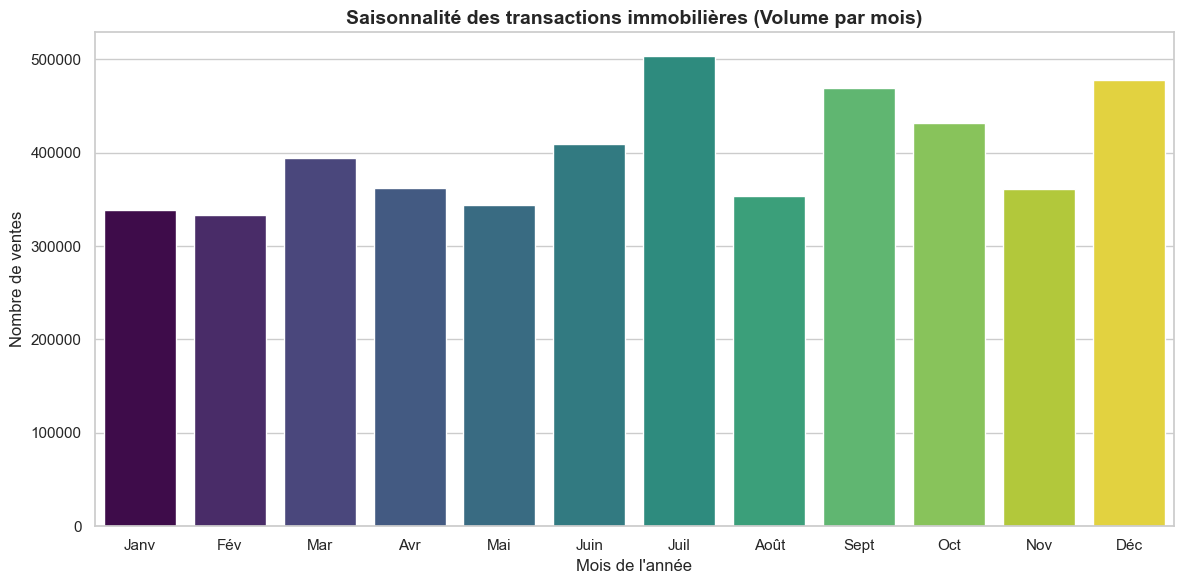

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Création du graphique en barres
order_mois = range(1, 13) # Pour être sûr d'avoir l'ordre Janvier -> Décembre
ax = sns.countplot(data=df, x='mois_mutation', palette='viridis', hue='mois_mutation', legend=False)

# Personnalisation
plt.title('Saisonnalité des transactions immobilières (Volume par mois)', fontsize=14, fontweight='bold')
plt.xlabel('Mois de l\'année', fontsize=12)
plt.ylabel('Nombre de ventes', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Janv', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sept', 'Oct', 'Nov', 'Déc'])

plt.tight_layout()
plt.show()

### Boxplot : Impact du type de bien sur le prix (is_neuf)

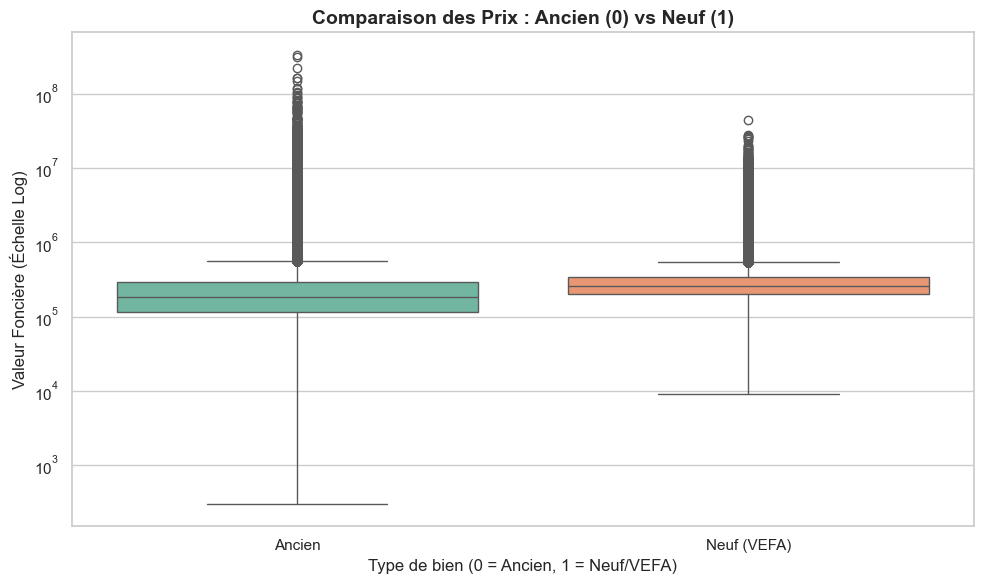

In [21]:
plt.figure(figsize=(10, 6))

# Création du Boxplot avec échelle log pour mieux voir la distribution
ax = sns.boxplot(data=df, x='is_neuf', y='valeur_fonciere', palette='Set2', hue='is_neuf', legend=False)

# Passage en échelle logarithmique pour la lecture
ax.set_yscale("log")

# Personnalisation
plt.title('Comparaison des Prix : Ancien (0) vs Neuf (1)', fontsize=14, fontweight='bold')
plt.xlabel('Type de bien (0 = Ancien, 1 = Neuf/VEFA)', fontsize=12)
plt.ylabel('Valeur Foncière (Échelle Log)', fontsize=12)
plt.xticks([0, 1], ['Ancien', 'Neuf (VEFA)'])

plt.tight_layout()
plt.show()

### Histogramme de la variable cible

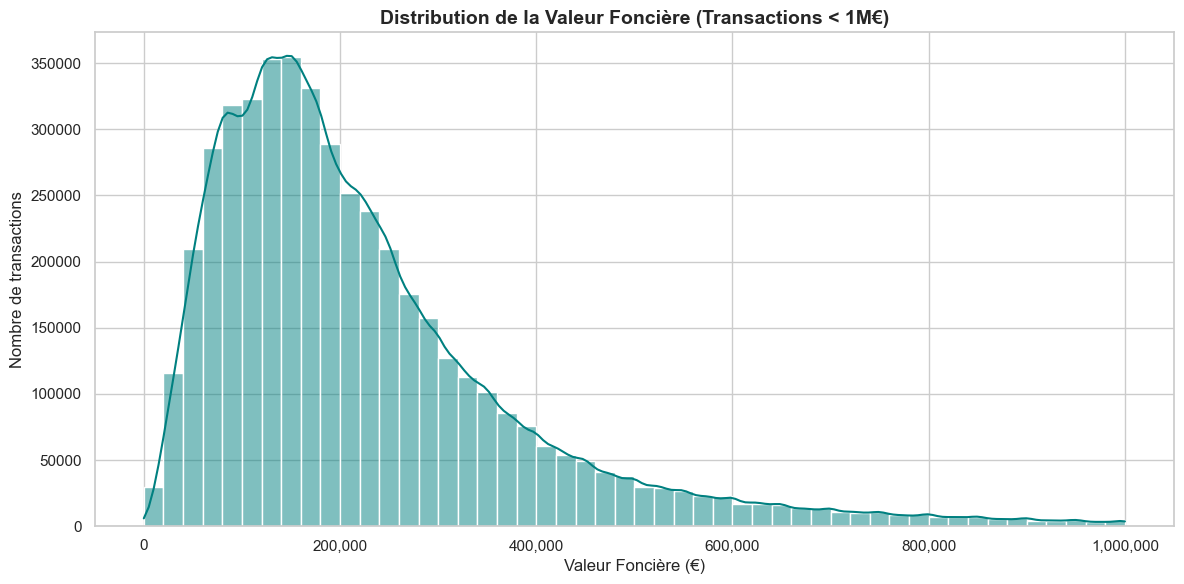

In [22]:
plt.figure(figsize=(12, 6))

# On filtre visuellement pour le graphique (jusqu'à 1M€) pour éviter d'écraser la courbe
# Cela permet de voir la "forme" réelle de la distribution
data_plot = df[df['valeur_fonciere'] <= 1000000]

sns.histplot(data_plot['valeur_fonciere'], bins=50, kde=True, color='teal')

# Personnalisation
plt.title('Distribution de la Valeur Foncière (Transactions < 1M€)', fontsize=14, fontweight='bold')
plt.xlabel('Valeur Foncière (€)', fontsize=12)
plt.ylabel('Nombre de transactions', fontsize=12)

# Amélioration du format des axes (milliers d'euros)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# C. Bloc de Localisation (Géo-intelligence)
longitude & latitude 
code_postal, code_commune, nom_commune, code_departement
adresse_numero, adresse_nom_voie, adresse_code_voie


In [23]:
# S'assurer que les codes sont des strings de la bonne longueur
df['code_postal'] = df['code_postal'].astype(str).str.replace('.0', '').str.zfill(5)
df['code_commune'] = df['code_commune'].astype(str).str.zfill(5)
df['code_departement'] = df['code_departement'].astype(str).str.zfill(2)

In [24]:
# Check des valeurs manquantes pour le bloc Géo
geo_cols = ['longitude', 'latitude', 'code_postal', 'code_commune', 'code_departement']
print("Valeurs manquantes par colonne (en %) :")
print((df[geo_cols].isnull().sum() / len(df) * 100).round(2))

Valeurs manquantes par colonne (en %) :
longitude           1.43
latitude            1.43
code_postal         0.00
code_commune        0.00
code_departement    0.00
dtype: float64


In [25]:
# On s'assure que le département est traité comme du texte
df['code_departement'] = df['code_departement'].astype(str).str.zfill(2)

# Correction spécifique pour la Corse si elle a été mal importée (ex: '20' au lieu de '2A'/'2B')
# Note : Dans DVF, ils sont généralement bien typés '2A' et '2B'.
print("Vérification des codes Corse présents :")
print(df[df['code_departement'].isin(['2A', '2B', '20'])]['code_departement'].unique())

Vérification des codes Corse présents :
<ArrowStringArray>
['2A', '2B']
Length: 2, dtype: str


In [26]:
# Suppression des lignes sans coordonnées GPS
df = df.dropna(subset=['latitude', 'longitude'])

print(f"Volume final après nettoyage géo : {len(df)} lignes.")

Volume final après nettoyage géo : 4713078 lignes.


In [27]:
# --- ÉTAPE 1 : Normalisation des formats ---
# Le code commune est la clé pivot (doit faire 5 caractères)
df['code_commune'] = df['code_commune'].astype(str).str.zfill(5)

# Le code département doit gérer 2A, 2B et les DROM
df['code_departement'] = df['code_departement'].astype(str).str.zfill(2)

# --- ÉTAPE 2 : Feature Engineering sur l'adresse ---
# On extrait le type de voie (Rue, Avenue, etc.) pour capter une tendance de prix
# sans pour autant garder le nom de la rue complet (trop de bruit)
df['type_voie'] = df['adresse_nom_voie'].str.split().str[0].str.upper()

# --- ÉTAPE 3 : Nettoyage définitif ---
# Nous supprimons le nom_commune car le code_commune est plus fiable pour les jointures.
# Nous supprimons l'adresse précise pour éviter l'overfitting.
cols_finales_geo = [
    'adresse_numero', 
    'adresse_nom_voie', 
    'adresse_code_voie', 
    'nom_commune'
]
df = df.drop(columns=cols_finales_geo)

print(f"✅ Bloc Géo finalisé. Volume : {len(df)} lignes.")
print(f"Colonnes géo conservées : {df.columns.intersection(['longitude', 'latitude', 'code_postal', 'code_commune', 'code_departement', 'type_voie']).tolist()}")

✅ Bloc Géo finalisé. Volume : 4713078 lignes.
Colonnes géo conservées : ['code_postal', 'code_commune', 'code_departement', 'longitude', 'latitude', 'type_voie']


# D. Caractéristiques Physiques du Bien
surface_reelle_bati
nombre_pieces_principales
surface_terrain & nature_culture 
nombre_lots


In [28]:
# Groupement par type de bien pour voir les moyennes de surface et de pièces
stats_croisees = df.groupby('type_local').agg({
    'surface_reelle_bati': ['mean', 'median', 'min', 'max'],
    'nombre_pieces_principales': ['mean', 'median', 'min', 'max'],
    'valeur_fonciere': ['mean', 'median']
}).round(2)

print("Statistiques par type de bien :")
print(stats_croisees)

Statistiques par type de bien :
            surface_reelle_bati                        \
                           mean median  min       max   
type_local                                              
Appartement               71.41   59.0  1.0  482562.0   
Maison                   128.99  100.0  1.0  606637.0   

            nombre_pieces_principales                      valeur_fonciere  \
                                 mean median  min      max            mean   
type_local                                                                   
Appartement                      3.25    3.0  0.0  23401.0       248105.23   
Maison                           5.27    4.0  0.0  28752.0       261242.25   

                       
               median  
type_local             
Appartement  170000.0  
Maison       200000.0  


In [29]:
# 1. Identifier les biens avec 0 pièces
print(f"Biens à 0 pièces : {len(df[df['nombre_pieces_principales'] == 0])}")

# 2. Identifier les surfaces bati suspectes (ex: moins de 9m2 pour de l'habitation)
surface_mini = df[df['surface_reelle_bati'] < 9]
print(f"Biens < 9m2 : {len(surface_mini)}")

# 3. Calcul du ratio pour détecter les erreurs de saisie
df['ratio_surf_piece'] = df['surface_reelle_bati'] / df['nombre_pieces_principales'].replace(0, 1)

# On regarde les extrêmes (le 1% et le 99% percentile)
limite_basse = df['ratio_surf_piece'].quantile(0.01)
limite_haute = df['ratio_surf_piece'].quantile(0.99)

print(f"Ratio Surface/Pièce : Alerte si < {limite_basse:.2f} ou > {limite_haute:.2f}")

Biens à 0 pièces : 4146
Biens < 9m2 : 1397
Ratio Surface/Pièce : Alerte si < 12.00 ou > 50.00


In [30]:
# Analyse des NaN sur le terrain par type de bien
nan_terrain_stats = df[df['surface_terrain'].isna()]['type_local'].value_counts()
print("Répartition des NaN (surface_terrain) par type de bien :")
print(nan_terrain_stats)

# Comparaison : Pourcentage de NaN au sein de chaque catégorie
total_maisons = len(df[df['type_local'] == 'Maison'])
total_apparts = len(df[df['type_local'] == 'Appartement'])

nan_maisons = df[(df['type_local'] == 'Maison') & (df['surface_terrain'].isna())].shape[0]
nan_apparts = df[(df['type_local'] == 'Appartement') & (df['surface_terrain'].isna())].shape[0]

print(f"\nPart de NaN chez les Maisons : {round(nan_maisons/total_maisons*100, 2)}%")
print(f"Part de NaN chez les Appartements : {round(nan_apparts/total_apparts*100, 2)}%")

Répartition des NaN (surface_terrain) par type de bien :
Series([], Name: count, dtype: int64)

Part de NaN chez les Maisons : 0.0%
Part de NaN chez les Appartements : 0.0%


In [31]:
# Vérifier combien de terrains sont à 0
zero_terrain_maison = len(df[(df['type_local'] == 'Maison') & (df['surface_terrain'] == 0)])
zero_terrain_appart = len(df[(df['type_local'] == 'Appartement') & (df['surface_terrain'] == 0)])

print(f"Maisons avec terrain à 0 : {zero_terrain_maison}")
print(f"Appartements avec terrain à 0 : {zero_terrain_appart}")

Maisons avec terrain à 0 : 126293
Appartements avec terrain à 0 : 2001572


In [32]:
# Vérifier si Terrain == Bâti
egalite_surface = len(df[df['surface_terrain'] == df['surface_reelle_bati']])
print(f"Nombre de biens où Terrain == Bâti : {egalite_surface}")

Nombre de biens où Terrain == Bâti : 8025


In [33]:
# --- ÉTAPE 1 : Sauvetage des "0 pièces" (Studios) ---
# Si le bien fait plus de 9m2, on lui attribue au moins 1 pièce
df.loc[(df['nombre_pieces_principales'] == 0) & (df['surface_reelle_bati'] >= 9), 'nombre_pieces_principales'] = 1

# --- ÉTAPE 2 : Création des variables binaires (Option C) ---
# 'has_terrain' : 1 si le terrain > 0, sinon 0
df['has_terrain'] = (df['surface_terrain'] > 0).astype(int)

# --- ÉTAPE 3 : Filtrage des incohérences physiques (Chirurgie) ---
# On applique les seuils de surface décidés ensemble
df = df[
    ((df['type_local'] == 'Appartement') & (df['surface_reelle_bati'].between(9, 250))) |
    ((df['type_local'] == 'Maison') & (df['surface_reelle_bati'].between(20, 500)))
]

# Suppression des erreurs de ratio extrêmes (ex: moins de 7m2 par pièce)
df = df[(df['surface_reelle_bati'] / df['nombre_pieces_principales']) >= 7]

# --- ÉTAPE 4 : Nettoyage final des colonnes physiques ---
# On s'assure que le nombre de lots est rempli (0 si vide)
df['nombre_lots'] = df['nombre_lots'].fillna(0).astype(int)

print(f"✅ Bloc Physique finalisé.")
print(f"Volume final : {len(df)} lignes.")
print(f"Colonnes créées/modifiées : ['has_terrain', 'nombre_pieces_principales']")

✅ Bloc Physique finalisé.
Volume final : 4651740 lignes.
Colonnes créées/modifiées : ['has_terrain', 'nombre_pieces_principales']


In [34]:
# On regarde la distribution des terrains pour les appartements uniquement
print("Top 10 des surfaces de terrain pour les appartements :")
print(df[df['type_local'] == 'Appartement']['surface_terrain'].value_counts().head(10))

# On vérifie combien d'appartements ont un terrain > 500 m2
big_terrain_apparts = len(df[(df['type_local'] == 'Appartement') & (df['surface_terrain'] > 500)])
print(f"Nombre d'appartements avec terrain > 500m2 : {big_terrain_apparts}")

Top 10 des surfaces de terrain pour les appartements :
surface_terrain
0.0      1992388
240.0        399
180.0        398
120.0        394
150.0        386
300.0        353
360.0        337
160.0        318
210.0        314
270.0        303
Name: count, dtype: int64
Nombre d'appartements avec terrain > 500m2 : 51425


In [35]:
# --- ÉTAPE 1 : Création de la variable de confort ---
# On marque d'un 1 tout bien qui a un accès extérieur (jardin/terrasse)
df['has_terrain'] = (df['surface_terrain'] > 0).astype(int)

# --- ÉTAPE 2 : Normalisation des surfaces d'appartements ---
# On plafonne à 200m2. Pourquoi ? Parce qu'un jardin privatif d'appart 
# dépasse rarement cette taille. Au-delà, c'est du bruit de copropriété.
mask_appart_grand_terrain = (df['type_local'] == 'Appartement') & (df['surface_terrain'] > 200)
df.loc[mask_appart_grand_terrain, 'surface_terrain'] = 200

# --- ÉTAPE 3 : Nettoyage et suppression des colonnes inutiles ---
# nature_culture est trop fragmentée, on la supprime comme convenu.
cols_to_drop = ['nature_culture']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"✅ Bloc D (Caractéristiques physiques) : Terminé.")
print(f"Statut : Terrains d'appartements plafonnés à 200m2. Variable 'has_terrain' créée.")

✅ Bloc D (Caractéristiques physiques) : Terminé.
Statut : Terrains d'appartements plafonnés à 200m2. Variable 'has_terrain' créée.


In [40]:
# 1. Liste des variantes possibles à supprimer pour être tranquille
variantes_nature = ['nature_culture', 'code_nature_culture', 'libelle_nature_culture']

# 2. Suppression sécurisée (si elles existent)
df = df.drop(columns=[col for col in variantes_nature if col in df.columns])

# 3. Vérification immédiate du nombre de colonnes et des NaNs
print("--- VÉRIFICATION POST-SUPPRESSION ---")
print(f"Nombre de colonnes restantes : {len(df.columns)}")
print("\n--- COMPTE DES NaNs PAR COLONNE ---")
missing_final = df.isnull().sum()
print(missing_final[missing_final > 0] if missing_final.any() else "Parfait : 0 NaN sur l'ensemble du dataset ! ✅")

# 4. Affichage des 5 premières lignes pour confirmer visuellement
df.head()

--- VÉRIFICATION POST-SUPPRESSION ---
Nombre de colonnes restantes : 24

--- COMPTE DES NaNs PAR COLONNE ---
code_postal    215
type_voie      138
dtype: int64


,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_postal,code_commune,code_departement,id_parcelle,nombre_lots,code_type_local,...,longitude,latitude,annee_mutation,mois_mutation,jour_semaine,is_neuf,type_voie,ratio_surf_piece,has_terrain,prix_m2
id_mutation,,,,,,,,,,,,,,,,,,,,,
2020-100,2020-07-16,1,Vente,22000.0,01160,01273,01,01273000AD0038,0,1.0,...,5.375781,46.079010,2020,7,3,0,RUE,32.000000,1,229.166667
2020-100000,2020-09-19,1,Vente,93300.0,14390,14724,14,14724000AI0035,1,2.0,...,-0.156799,49.283990,2020,9,5,0,AV,13.000000,0,3588.461538
2020-100001,2020-09-10,1,Vente,223000.0,14310,14752,14,14752000AK0149,0,1.0,...,-0.654175,49.075644,2020,9,3,0,SQ,22.600000,1,1973.451327
2020-100002,2020-09-17,1,Vente,194000.0,14440,14228,14,14228000AD0312,0,1.0,...,-0.371700,49.290278,2020,9,3,0,RUE,23.333333,1,2771.428571
2020-100004,2020-09-10,1,Vente,83000.0,14810,14409,14,14409000AA0192,1,2.0,...,-0.204951,49.284326,2020,9,3,0,AV,26.000000,0,1596.153846


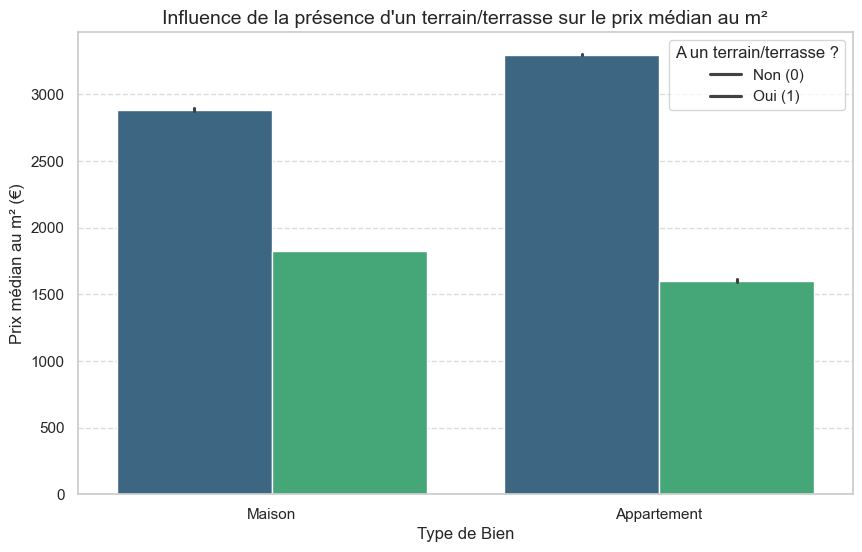

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcul du prix au m2 pour le graphique
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']

# 2. Création du graphique
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='type_local', y='prix_m2', hue='has_terrain', palette='viridis', estimator='median')

# 3. Cosmétique
plt.title('Influence de la présence d\'un terrain/terrasse sur le prix médian au m²', fontsize=14)
plt.xlabel('Type de Bien', fontsize=12)
plt.ylabel('Prix médian au m² (€)', fontsize=12)
plt.legend(title='A un terrain/terrasse ?', labels=['Non (0)', 'Oui (1)'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

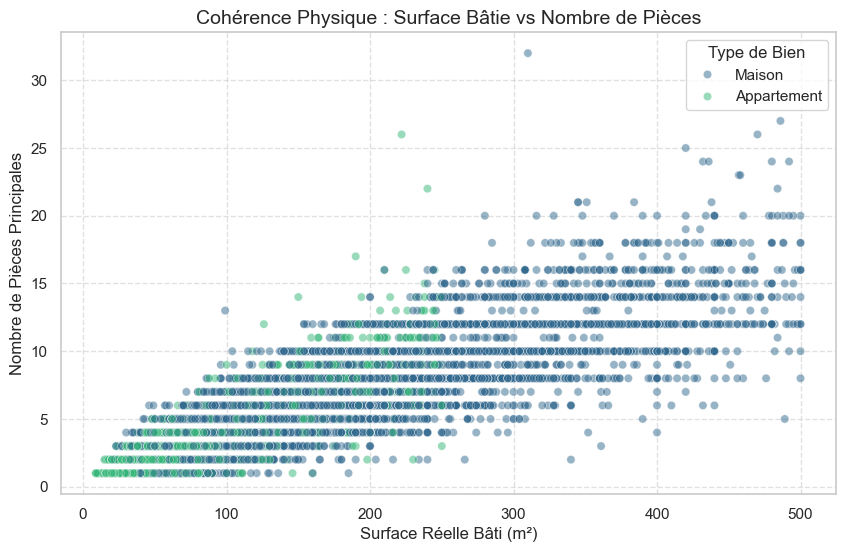

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Création du nuage de points
# On utilise un échantillon (sample) de 50 000 points si le dataset est trop lourd pour l'affichage
sns.scatterplot(data=df.sample(min(50000, len(df))), 
                x='surface_reelle_bati', 
                y='nombre_pieces_principales', 
                hue='type_local', 
                alpha=0.5, 
                palette='viridis')

# Ajout d'une ligne de tendance pour visualiser la cohérence
plt.title('Cohérence Physique : Surface Bâtie vs Nombre de Pièces', fontsize=14)
plt.xlabel('Surface Réelle Bâti (m²)', fontsize=12)
plt.ylabel('Nombre de Pièces Principales', fontsize=12)
plt.legend(title='Type de Bien')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Verification finale fichier avant enregistrement et ML

In [41]:
# 1. Vérification des colonnes restantes
print("--- COLONNES PRÉSENTES ---")
print(df.columns.tolist())

# 2. Décompte précis des valeurs manquantes par colonne
print("\n--- VALEURS MANQUANTES (NaN) ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.any() else "Aucun NaN détecté ! ✅")

# 3. Vérification des types de données (Dtypes)
print("\n--- TYPES DE DONNÉES ---")
print(df.dtypes)

--- COLONNES PRÉSENTES ---
['date_mutation', 'numero_disposition', 'nature_mutation', 'valeur_fonciere', 'code_postal', 'code_commune', 'code_departement', 'id_parcelle', 'nombre_lots', 'code_type_local', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'longitude', 'latitude', 'annee_mutation', 'mois_mutation', 'jour_semaine', 'is_neuf', 'type_voie', 'ratio_surf_piece', 'has_terrain', 'prix_m2']

--- VALEURS MANQUANTES (NaN) ---
code_postal    215
type_voie      138
dtype: int64

--- TYPES DE DONNÉES ---
date_mutation                datetime64[us]
numero_disposition                    int64
nature_mutation                         str
valeur_fonciere                     float64
code_postal                             str
code_commune                            str
code_departement                        str
id_parcelle                             str
nombre_lots                           int64
code_type_local                     float64
type_local   

In [42]:
# Exportation propre
df.to_csv('dvf_clean_final_avantML.csv', index=False)
print("🚀 Fichier exporté ! Le Bloc D est officiellement validé.")

🚀 Fichier exporté ! Le Bloc D est officiellement validé.


## PARTIE 2 : ANALYSE EXPLORATOIRE (EDA)

## Heatpmap : Matrice de corrélation de Pearson

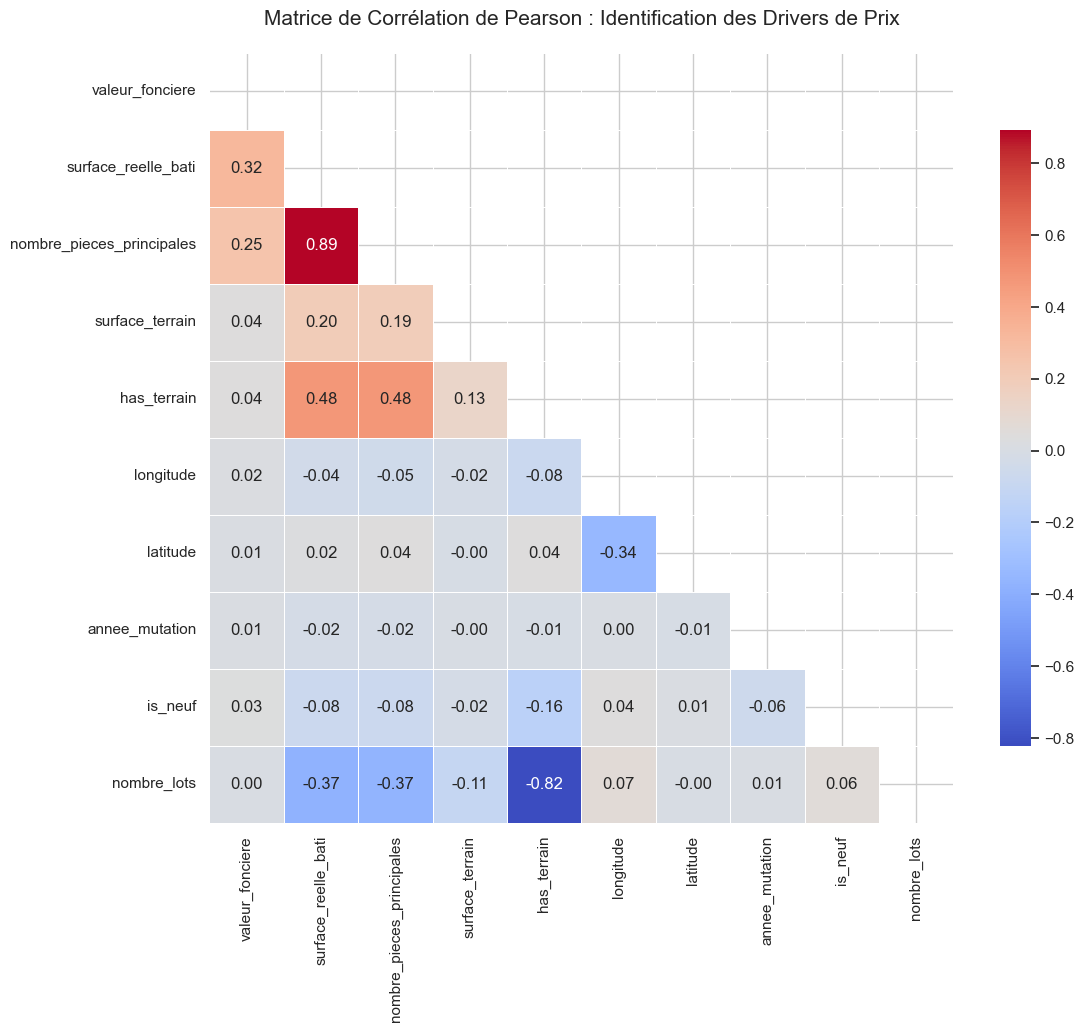

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sélection des variables numériques pertinentes
cols_for_corr = ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 
                 'surface_terrain', 'has_terrain', 'longitude', 'latitude', 
                 'annee_mutation', 'is_neuf', 'nombre_lots']

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df[cols_for_corr].corr(), dtype=bool)) # Masque pour la moitié supérieure

sns.heatmap(df[cols_for_corr].corr(), 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', # Plus pro que RdYlGn pour les corrélations
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title("Matrice de Corrélation de Pearson : Identification des Drivers de Prix", fontsize=15, pad=20)
plt.show()

## Distributions et la Log-Transformation

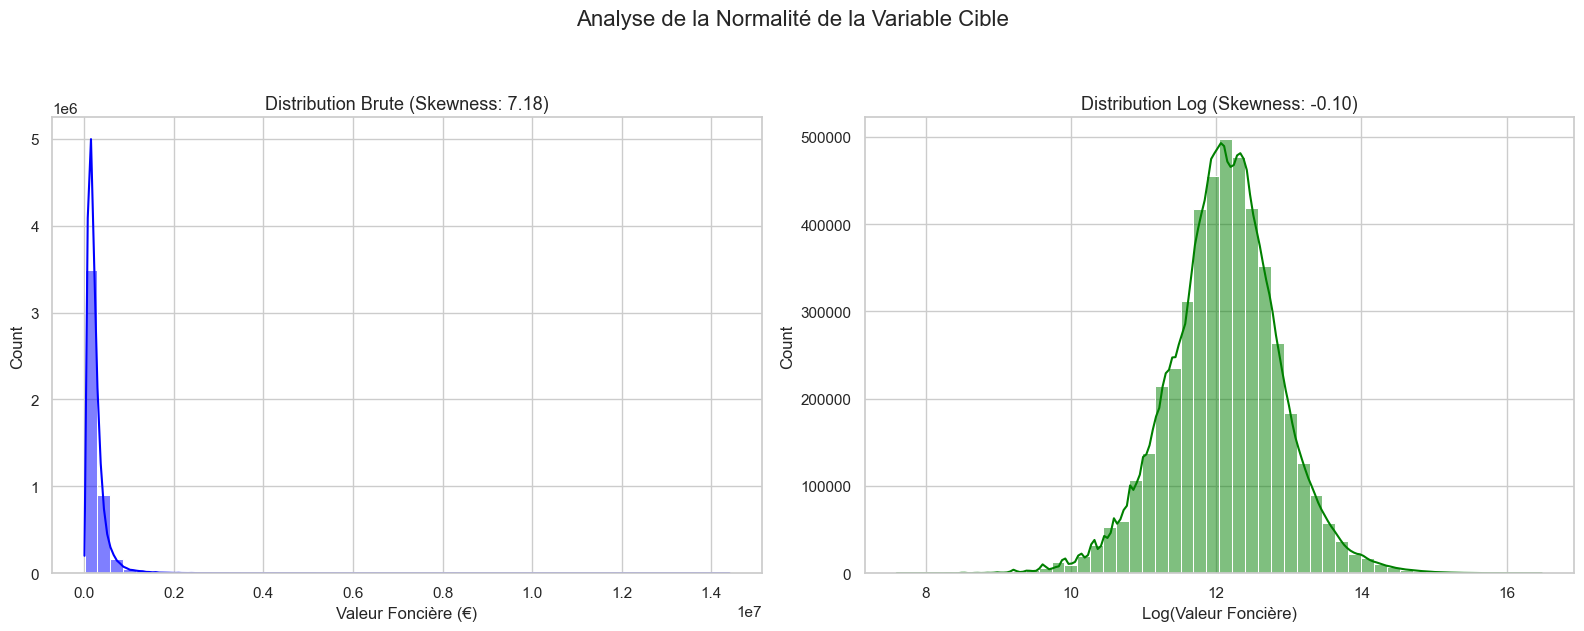

In [45]:
import scipy.stats as stats

plt.figure(figsize=(16, 6))

# 1. Distribution du prix brut
plt.subplot(1, 2, 1)
sns.histplot(df['valeur_fonciere'], kde=True, color='blue', bins=50)
plt.title(f"Distribution Brute (Skewness: {df['valeur_fonciere'].skew():.2f})", fontsize=13)
plt.xlabel("Valeur Foncière (€)")

# 2. Distribution après Log-transformation
plt.subplot(1, 2, 2)
# On utilise log1p pour gérer les valeurs très petites (log(1+x))
log_valeur = np.log1p(df['valeur_fonciere'])
sns.histplot(log_valeur, kde=True, color='green', bins=50)
plt.title(f"Distribution Log (Skewness: {log_valeur.skew():.2f})", fontsize=13)
plt.xlabel("Log(Valeur Foncière)")

plt.suptitle("Analyse de la Normalité de la Variable Cible", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Relation Surace/prix par Type de biens

<Figure size 1200x1000 with 0 Axes>

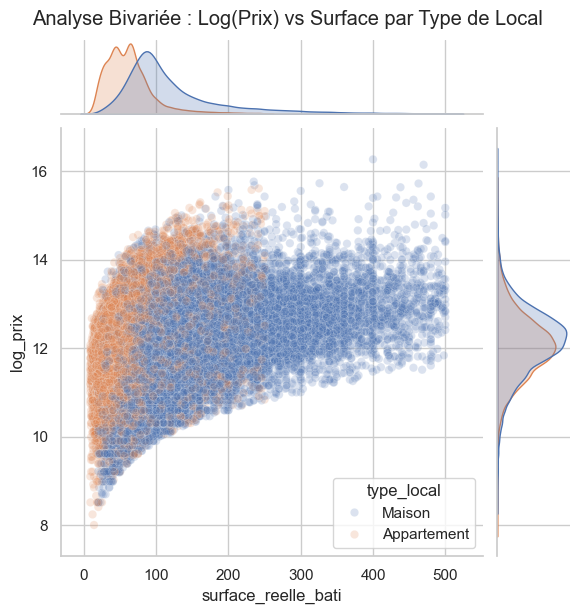

In [46]:
# On crée une colonne temporaire pour la visualisation
df['log_prix'] = np.log1p(df['valeur_fonciere'])

plt.figure(figsize=(12, 10))
g = sns.JointGrid(data=df.sample(100000), x="surface_reelle_bati", y="log_prix", hue="type_local")
g.plot_joint(sns.scatterplot, alpha=0.2)
g.plot_marginals(sns.kdeplot, fill=True)

plt.suptitle("Analyse Bivariée : Log(Prix) vs Surface par Type de Local", y=1.02)
plt.show()

## Dimension spatiale

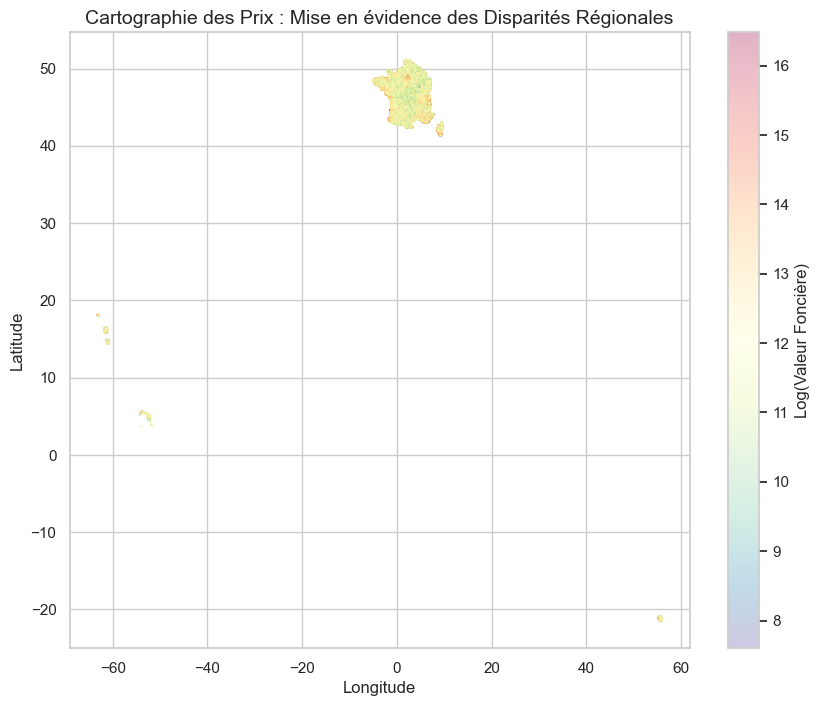

In [47]:
plt.figure(figsize=(10, 8))
# On utilise le log_prix pour que les couleurs soient plus contrastées et parlantes
plt.scatter(df['longitude'], df['latitude'], c=df['log_prix'], 
            cmap='Spectral_r', s=0.5, alpha=0.3)

plt.colorbar(label='Log(Valeur Foncière)')
plt.title("Cartographie des Prix : Mise en évidence des Disparités Régionales", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

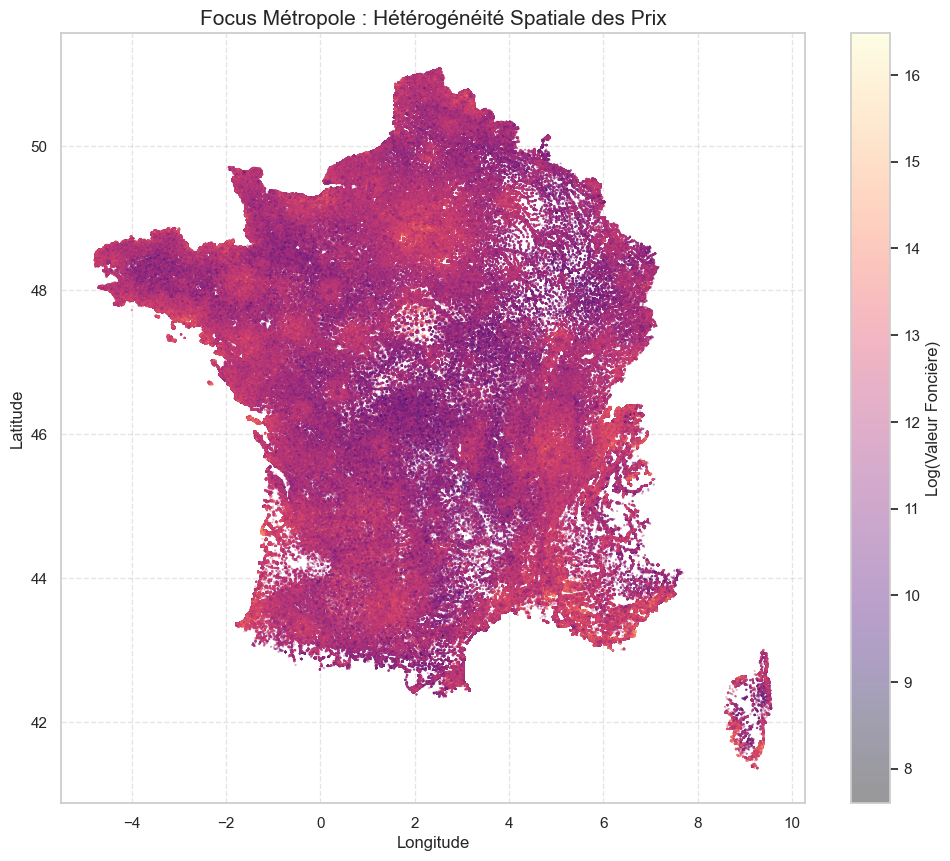

In [48]:
plt.figure(figsize=(12, 10))

# Filtrage pour la métropole uniquement
df_metropole = df[(df['longitude'] > -5) & (df['longitude'] < 10) & 
                  (df['latitude'] > 41) & (df['latitude'] < 52)]

# Visualisation avec une palette plus contrastée (magma ou viridis)
sc = plt.scatter(df_metropole['longitude'], df_metropole['latitude'], 
                 c=df_metropole['log_prix'], 
                 cmap='magma', s=0.3, alpha=0.4)

plt.colorbar(sc, label='Log(Valeur Foncière)')
plt.title("Focus Métropole : Hétérogénéité Spatiale des Prix", fontsize=15)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Optionnel : Fond de carte très léger si tu as les bibliothèques, 
# sinon le nuage de points dessine lui-même la forme de la France.
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()